# 3.0 — Consolidated Classifier Comparison

Loads every saved model checkpoint, re-runs inference on the **same** val/test splits,
and reports accuracy, AUC-ROC, and **PR-AUC** for all experiments so the README table
(section 1.3.4 *Consolidated Test-Set Results*) can be updated.

| Notebook | Model family | Checkpoint |
|---|---|---|
| 1.0 | SimpleCNN (baseline) | `baseline_cnn_20260516-164040.pt` |
| 1.1 | FrozenResNet-18 | `resnet18_20260518-110522.pt` |
| 1.2 | SimpleCNN + augmentation | `augmented_cnn_20260517-172811.pt` |
| 1.3 | FrozenDenseNet-121 | `densenet121_20260518-094701.pt` |
| 1.6 | CheXNet oracle | `chexnet.pth.tar` |
| 2.0.1 | CheXNet + CycleGAN H2P aug | `chexnet_finetune_synthetic.pt` |
| 2.0.2 | CheXNet + CycleGAN H2P flipped only | `chexnet_finetune_synthetic_flipped.pt` |
| 2.1.1 | CheXNet + CVAE H2P aug | `chexnet_finetune_synthetic_cvae.pt` |
| 2.1.2 | CheXNet + CVAE H2P flipped only | `chexnet_finetune_synthetic_cvae_flipped.pt` |

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import roc_curve

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "utils"))

from models.Classifier.classifier import (
    SimpleCNN, FrozenResNet18, FrozenDenseNet121, CheXNet, CheXNetLinearProbe,
)
from utils.metrics import compute_roc_auc, compute_pr_auc, compute_accuracy, compute_confusion_matrix

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

CHKPT_DIR    = PROJECT_ROOT / "models" / "Classifier"
CHEXNET_CKPT = CHKPT_DIR / "chexnet.pth.tar"
RESULTS_DIR  = PROJECT_ROOT / "results"

Device: cpu


## 1. Load val / test datasets

In [2]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_v2"

val_ds  = torch.load(PROCESSED_DIR / "val_dataset.pt",  weights_only=False)
test_ds = torch.load(PROCESSED_DIR / "test_dataset.pt", weights_only=False)

print(f"Val  set: {len(val_ds):,} images")
print(f"Test set: {len(test_ds):,} images")

for name, ds in [("val", val_ds), ("test", test_ds)]:
    n_pos = int(ds.labels[:, 1].sum())
    print(f"  [{name}] pneumonia={n_pos}  healthy={len(ds)-n_pos}")

Val  set: 8,993 images
Test set: 9,021 images
  [val] pneumonia=54  healthy=8939
  [test] pneumonia=43  healthy=8978


## 2. Inference helpers

In [3]:
class ResizingDataset(Dataset):
    """Wraps a PyTorchDataset, resizes to *size* on the fly, returns (img, binary_label)."""

    def __init__(self, base_ds, size: int = 224):
        self.base   = base_ds
        self.resize = transforms.Resize((size, size), antialias=True)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label, _ = self.base[idx]   # (1, H, W), one-hot (2,), metadata
        return self.resize(img), label[1].float()   # 1 = pneumonia

In [4]:
def get_scores(model, ds, device, img_size: int = 224, batch_size: int = 64):
    """Return (scores, labels) float32 arrays for *ds* using *model*."""
    loader = DataLoader(
        ResizingDataset(ds, img_size),
        batch_size=batch_size, shuffle=False, num_workers=0,
    )
    scores, labels = [], []
    model.eval()
    with torch.inference_mode():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            if isinstance(model, CheXNet):
                probs = model.predict_pneumonia(imgs).cpu()
            else:
                probs = torch.sigmoid(model(imgs)).cpu().squeeze(-1)
            scores.extend(probs.tolist())
            labels.extend(lbls.tolist())
    return np.array(scores, dtype=np.float32), np.array(labels, dtype=np.float32)


def youden_threshold(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    return float(thresholds[np.argmax(tpr - fpr)])


def evaluate(model, val_ds, test_ds, device, img_size: int = 224):
    """Full evaluation pipeline: val threshold + test metrics."""
    val_sc, val_y   = get_scores(model, val_ds,  device, img_size)
    test_sc, test_y = get_scores(model, test_ds, device, img_size)

    thr     = youden_threshold(val_y, val_sc)
    auc_roc = compute_roc_auc(test_y, test_sc)
    pr_auc  = compute_pr_auc(test_y, test_sc)
    acc     = compute_accuracy(test_y, test_sc, threshold=thr)
    cm      = compute_confusion_matrix(test_y, test_sc, threshold=thr)

    return {
        "threshold":     round(thr, 4),
        "test_auc_roc":  round(float(auc_roc), 4),
        "test_pr_auc":   round(float(pr_auc),  4),
        "test_accuracy": round(float(acc),     4),
        "cm":            cm,
        "y_scores":      test_sc,
        "y_true":        test_y,
    }

## 3. Model configurations

In [5]:
def _load_simplecnn(ckpt, dropout=0.3):
    m = SimpleCNN(dropout_rate=dropout)
    m.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=False))
    return m

def _load_resnet18(ckpt):
    m = FrozenResNet18()
    m.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=False))
    return m

def _load_densenet121(ckpt):
    m = FrozenDenseNet121()
    m.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=False))
    return m

def _load_chexnet_oracle():
    return CheXNet(CHEXNET_CKPT)

def _load_chexnet_probe(ckpt):
    m = CheXNetLinearProbe(CHEXNET_CKPT)
    m.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=False))
    return m


EXPERIMENTS = [
    {
        "notebook":   "1.0",
        "model_name": "SimpleCNN (baseline)",
        "train_data": "Original",
        "loader":     lambda: _load_simplecnn(CHKPT_DIR / "baseline_cnn_20260516-164040.pt"),
        "json_path":  RESULTS_DIR / "baseline_cnn_20260516-164040" / "baseline_results.json",
    },
    {
        "notebook":   "1.1",
        "model_name": "FrozenResNet-18",
        "train_data": "Original",
        "loader":     lambda: _load_resnet18(CHKPT_DIR / "resnet18_20260518-110522.pt"),
        "json_path":  RESULTS_DIR / "resnet18_20260518-110522" / "resnet18_results.json",
    },
    {
        "notebook":   "1.2",
        "model_name": "SimpleCNN + augmentation",
        "train_data": "Original + aug",
        "loader":     lambda: _load_simplecnn(CHKPT_DIR / "augmented_cnn_20260517-172811.pt"),
        "json_path":  RESULTS_DIR / "augmented_cnn_20260517-172811" / "SimpleCNN_augmented_results.json",
    },
    {
        "notebook":   "1.3",
        "model_name": "FrozenDenseNet-121",
        "train_data": "Original",
        "loader":     lambda: _load_densenet121(CHKPT_DIR / "densenet121_20260518-094701.pt"),
        "json_path":  RESULTS_DIR / "densenet121_20260518-094701" / "resnet18_results.json",
    },
    {
        "notebook":   "1.6",
        "model_name": "CheXNet (oracle)",
        "train_data": "ChestX-ray14 (frozen)",
        "loader":     _load_chexnet_oracle,
        "json_path":  None,
    },
    {
        "notebook":   "2.0.1",
        "model_name": "CheXNet + CycleGAN H2P",
        "train_data": "Original + CycleGAN H2P",
        "loader":     lambda: _load_chexnet_probe(CHKPT_DIR / "chexnet_finetune_synthetic.pt"),
        "json_path":  RESULTS_DIR / "chexnet_finetune_synthetic" / "results.json",
    },
    {
        "notebook":   "2.0.2",
        "model_name": "CheXNet + CycleGAN H2P (flipped only)",
        "train_data": "Original + CycleGAN H2P flipped",
        "loader":     lambda: _load_chexnet_probe(CHKPT_DIR / "chexnet_finetune_synthetic_flipped.pt"),
        "json_path":  None,
    },
    {
        "notebook":   "2.1.1",
        "model_name": "CheXNet + CVAE H2P",
        "train_data": "Original + CVAE H2P",
        "loader":     lambda: _load_chexnet_probe(CHKPT_DIR / "chexnet_finetune_synthetic_cvae.pt"),
        "json_path":  RESULTS_DIR / "chexnet_finetune_synthetic_cvae" / "results.json",
    },
    {
        "notebook":   "2.1.2",
        "model_name": "CheXNet + CVAE H2P (flipped only)",
        "train_data": "Original + CVAE H2P flipped",
        "loader":     lambda: _load_chexnet_probe(CHKPT_DIR / "chexnet_finetune_synthetic_cvae_flipped.pt"),
        "json_path":  RESULTS_DIR / "chexnet_finetune_synthetic_cvae_flipped" / "results.json",
    },
]

print(f"{len(EXPERIMENTS)} experiments configured.")

9 experiments configured.


## 4. Run inference on all models

All images are resized to 224 × 224 (training resolution) before inference.  
Decision thresholds are calibrated on the **val** set via Youden's J statistic.

In [6]:
from tqdm.auto import tqdm

results = {}

for exp in tqdm(EXPERIMENTS, desc="Evaluating"):
    nb   = exp["notebook"]
    name = exp["model_name"]
    print(f"\n[{nb}] {name}")

    model   = exp["loader"]().to(DEVICE)
    metrics = evaluate(model, val_ds, test_ds, DEVICE)
    results[nb] = {"name": name, "train_data": exp["train_data"], **metrics}

    print(
        f"  AUC-ROC={metrics['test_auc_roc']:.4f}  "
        f"PR-AUC={metrics['test_pr_auc']:.4f}  "
        f"Acc@Youden={metrics['test_accuracy']:.4f}  "
        f"(thr={metrics['threshold']:.4f})"
    )
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nDone.")

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]


[1.0] SimpleCNN (baseline)
  AUC-ROC=0.5684  PR-AUC=0.0074  Acc@Youden=0.5985  (thr=0.1909)

[1.1] FrozenResNet-18
  AUC-ROC=0.6986  PR-AUC=0.0138  Acc@Youden=0.6707  (thr=0.0738)

[1.2] SimpleCNN + augmentation
  AUC-ROC=0.5993  PR-AUC=0.0156  Acc@Youden=0.4013  (thr=0.1289)

[1.3] FrozenDenseNet-121
  AUC-ROC=0.6764  PR-AUC=0.0091  Acc@Youden=0.5437  (thr=0.1508)

[1.6] CheXNet (oracle)
  AUC-ROC=0.7423  PR-AUC=0.0170  Acc@Youden=0.6296  (thr=0.3414)

[2.0.1] CheXNet + CycleGAN H2P
  AUC-ROC=0.6863  PR-AUC=0.0135  Acc@Youden=0.5207  (thr=0.2388)

[2.0.2] CheXNet + CycleGAN H2P (flipped only)
  AUC-ROC=0.6659  PR-AUC=0.0132  Acc@Youden=0.6676  (thr=0.0809)

[2.1.1] CheXNet + CVAE H2P
  AUC-ROC=0.6731  PR-AUC=0.0074  Acc@Youden=0.5630  (thr=0.4365)

[2.1.2] CheXNet + CVAE H2P (flipped only)
  AUC-ROC=0.6699  PR-AUC=0.0109  Acc@Youden=0.7146  (thr=0.0337)

Done.


## 5. Consolidated results table

In [7]:
def _json_val_auc(json_path):
    if json_path is None or not Path(json_path).exists():
        return "—"
    with open(json_path) as f:
        d = json.load(f)
    key = next((k for k in ("best_val_auc",) if k in d), None)
    return f"{d[key]:.4f}" if key else "—"

def _json_stopped_at(json_path):
    if json_path is None or not Path(json_path).exists():
        return "—"
    with open(json_path) as f:
        d = json.load(f)
    hist = d.get("history", {})
    tl   = hist.get("train_loss", [])
    ep   = d.get("hyperparams", {}).get("epochs_trained") or (len(tl) if tl else None)
    return f"epoch {ep}" if ep else "—"


rows = []
for exp in EXPERIMENTS:
    nb = exp["notebook"]
    r  = results[nb]
    rows.append({
        "Notebook":           nb,
        "Model":              r["name"],
        "Training data":      r["train_data"],
        "Test AUC-ROC ↑":     r["test_auc_roc"],
        "Test PR-AUC ↑":      r["test_pr_auc"],
        "Test Acc (Youden)":  r["test_accuracy"],
        "Best Val AUC":       _json_val_auc(exp["json_path"]),
        "Stopped at":         _json_stopped_at(exp["json_path"]),
    })

df = pd.DataFrame(rows)
display(df.style
    .highlight_max(subset=["Test AUC-ROC ↑", "Test PR-AUC ↑"], color="lightgreen")
    .highlight_min(subset=["Test AUC-ROC ↑", "Test PR-AUC ↑"], color="#ffcccc")
    .format({"Test AUC-ROC ↑": "{:.4f}", "Test PR-AUC ↑": "{:.4f}", "Test Acc (Youden)": "{:.4f}"})
    .set_caption("Consolidated Test-Set Results — all models evaluated at 224 × 224")
)

,Notebook,Model,Training data,Test AUC-ROC ↑,Test PR-AUC ↑,Test Acc (Youden),Best Val AUC,Stopped at
0,1.0,SimpleCNN (baseline),Original,0.5684,0.0074,0.5985,0.6411,epoch 18
1,1.1,FrozenResNet-18,Original,0.6986,0.0138,0.6707,0.5758,epoch 20
2,1.2,SimpleCNN + augmentation,Original + aug,0.5993,0.0156,0.4013,0.6284,epoch 12
3,1.3,FrozenDenseNet-121,Original,0.6764,0.0091,0.5437,0.5406,epoch 13
4,1.6,CheXNet (oracle),ChestX-ray14 (frozen),0.7423,0.0170,0.6296,—,—
5,2.0.1,CheXNet + CycleGAN H2P,Original + CycleGAN H2P,0.6863,0.0135,0.5207,0.7028,epoch 6
6,2.0.2,CheXNet + CycleGAN H2P (flipped only),Original + CycleGAN H2P flipped,0.6659,0.0132,0.6676,—,—
7,2.1.1,CheXNet + CVAE H2P,Original + CVAE H2P,0.6731,0.0074,0.5630,0.6205,epoch 9
8,2.1.2,CheXNet + CVAE H2P (flipped only),Original + CVAE H2P flipped,0.6699,0.0109,0.7146,0.7126,epoch 10


## 6. ROC and PR curves

Saved to /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/classifier_comparison_curves.png


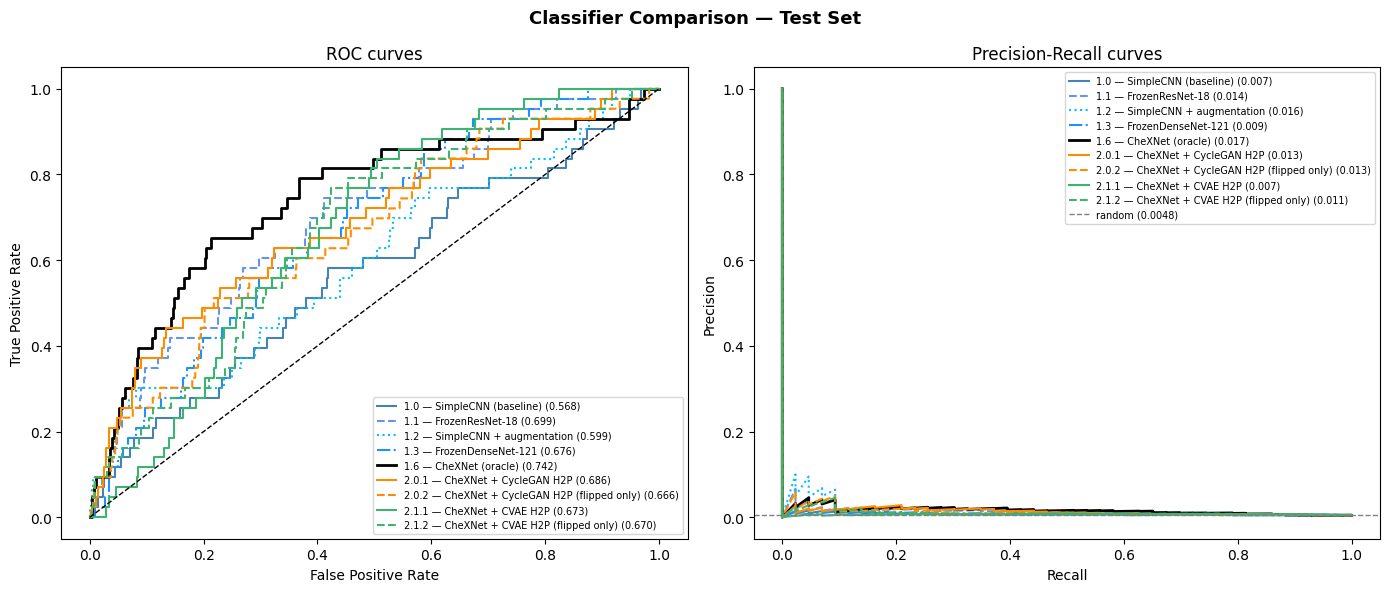

In [8]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax_roc, ax_pr = axes

_STYLES = {
    "1.0":   dict(color="steelblue",       linestyle="-"),
    "1.1":   dict(color="cornflowerblue",   linestyle="--"),
    "1.2":   dict(color="deepskyblue",      linestyle=":"),
    "1.3":   dict(color="dodgerblue",       linestyle="-."),
    "1.6":   dict(color="black",            linestyle="-",  linewidth=2),
    "2.0.1": dict(color="darkorange",       linestyle="-"),
    "2.0.2": dict(color="darkorange",       linestyle="--"),
    "2.1.1": dict(color="mediumseagreen",   linestyle="-"),
    "2.1.2": dict(color="mediumseagreen",   linestyle="--"),
}

for exp in EXPERIMENTS:
    nb             = exp["notebook"]
    r              = results[nb]
    y_true, y_sc   = r["y_true"], r["y_scores"]
    sty            = _STYLES.get(nb, {})
    lbl            = f"{nb} — {r['name']}"

    fpr, tpr, _    = roc_curve(y_true, y_sc)
    ax_roc.plot(fpr, tpr, label=f"{lbl} ({r['test_auc_roc']:.3f})", **sty)

    prec, rec, _   = precision_recall_curve(y_true, y_sc)
    ax_pr.plot(rec, prec, label=f"{lbl} ({r['test_pr_auc']:.3f})", **sty)

ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC curves")
ax_roc.legend(fontsize=7, loc="lower right")

prevalence = float(results[list(results)[0]]["y_true"].mean())
ax_pr.axhline(prevalence, color="gray", lw=1, linestyle="--", label=f"random ({prevalence:.4f})")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall curves")
ax_pr.legend(fontsize=7, loc="upper right")

fig.suptitle("Classifier Comparison — Test Set", fontsize=13, fontweight="bold")
fig.tight_layout()

save_path = RESULTS_DIR / "classifier_comparison_curves.png"
fig.savefig(save_path, dpi=150)
print(f"Saved to {save_path}")
plt.show()

## 7. Confusion matrices at Youden threshold

Saved to /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/classifier_comparison_cm.png


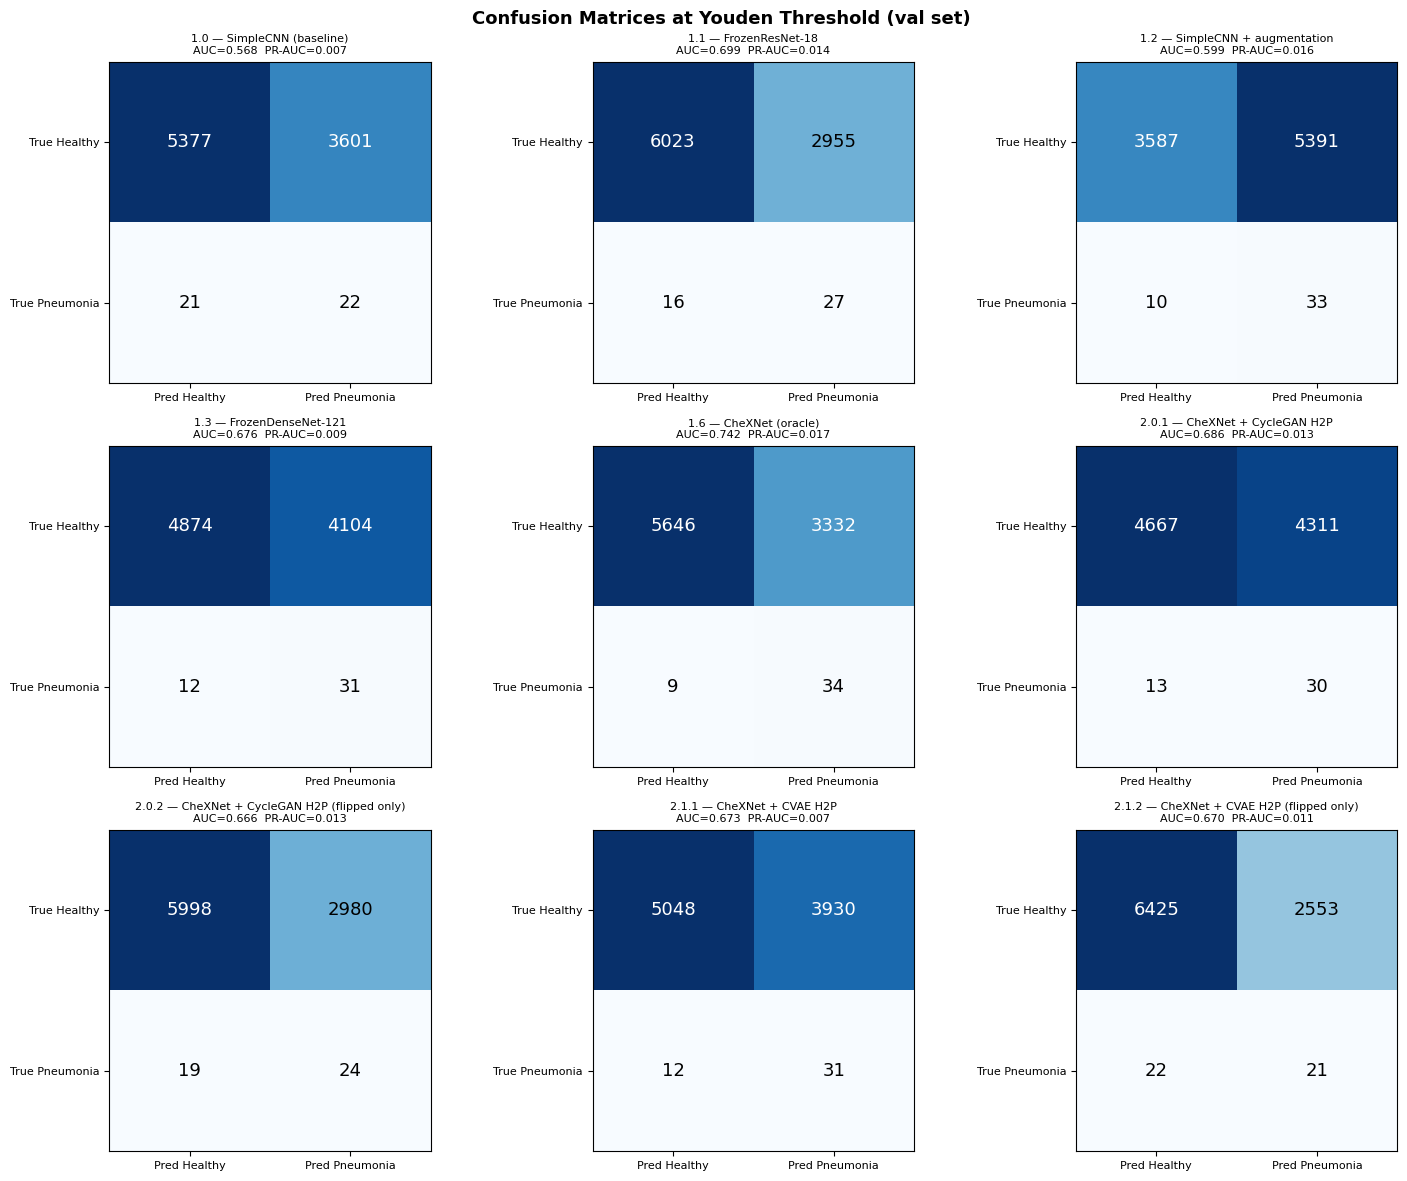

In [9]:
n_exp = len(EXPERIMENTS)
ncols = 3
nrows = (n_exp + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, exp in enumerate(EXPERIMENTS):
    nb          = exp["notebook"]
    r           = results[nb]
    tn, fp, fn, tp = r["cm"].ravel()
    total       = max(tn, fp, fn, tp)

    ax  = axes[i]
    mat = [[int(tn), int(fp)], [int(fn), int(tp)]]
    ax.imshow(mat, cmap="Blues")
    for row in range(2):
        for col in range(2):
            ax.text(col, row, str(mat[row][col]),
                    ha="center", va="center", fontsize=13,
                    color="white" if mat[row][col] > total / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Healthy", "Pred Pneumonia"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["True Healthy", "True Pneumonia"], fontsize=8)
    ax.set_title(
        f"{nb} — {r['name']}\n"
        f"AUC={r['test_auc_roc']:.3f}  PR-AUC={r['test_pr_auc']:.3f}",
        fontsize=8,
    )

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Confusion Matrices at Youden Threshold (val set)", fontsize=13, fontweight="bold")
fig.tight_layout()

save_path = RESULTS_DIR / "classifier_comparison_cm.png"
fig.savefig(save_path, dpi=150)
print(f"Saved to {save_path}")
plt.show()

## 8. README table (copy-paste into section 1.3.4)

The markdown below can be pasted directly into README.md section **1.3.4 Consolidated Test-Set Results**.

In [10]:
best_auc_nb   = max(results, key=lambda nb: results[nb]["test_auc_roc"])
best_prauc_nb = max(results, key=lambda nb: results[nb]["test_pr_auc"])

lines = [
    "| Notebook | Model | Training data | Test AUC-ROC ↑ | Test PR-AUC ↑ | Test Acc (Youden) | Best Val AUC | Stopped at |",
    "|---|---|---|---|---|---|---|---|",
]

for exp in EXPERIMENTS:
    nb  = exp["notebook"]
    r   = results[nb]

    auc_str   = f"**{r['test_auc_roc']:.4f}**" if nb == best_auc_nb   else f"{r['test_auc_roc']:.4f}"
    prauc_str = f"**{r['test_pr_auc']:.4f}**"  if nb == best_prauc_nb else f"{r['test_pr_auc']:.4f}"

    lines.append(
        f"| {nb} | {r['name']} | {r['train_data']} "
        f"| {auc_str} | {prauc_str} "
        f"| {r['test_accuracy']:.4f} "
        f"| {_json_val_auc(exp['json_path'])} "
        f"| {_json_stopped_at(exp['json_path'])} |"
    )

table_md = "\n".join(lines)
print(table_md)

| Notebook | Model | Training data | Test AUC-ROC ↑ | Test PR-AUC ↑ | Test Acc (Youden) | Best Val AUC | Stopped at |
|---|---|---|---|---|---|---|---|
| 1.0 | SimpleCNN (baseline) | Original | 0.5684 | 0.0074 | 0.5985 | 0.6411 | epoch 18 |
| 1.1 | FrozenResNet-18 | Original | 0.6986 | 0.0138 | 0.6707 | 0.5758 | epoch 20 |
| 1.2 | SimpleCNN + augmentation | Original + aug | 0.5993 | 0.0156 | 0.4013 | 0.6284 | epoch 12 |
| 1.3 | FrozenDenseNet-121 | Original | 0.6764 | 0.0091 | 0.5437 | 0.5406 | epoch 13 |
| 1.6 | CheXNet (oracle) | ChestX-ray14 (frozen) | **0.7423** | **0.0170** | 0.6296 | — | — |
| 2.0.1 | CheXNet + CycleGAN H2P | Original + CycleGAN H2P | 0.6863 | 0.0135 | 0.5207 | 0.7028 | epoch 6 |
| 2.0.2 | CheXNet + CycleGAN H2P (flipped only) | Original + CycleGAN H2P flipped | 0.6659 | 0.0132 | 0.6676 | — | — |
| 2.1.1 | CheXNet + CVAE H2P | Original + CVAE H2P | 0.6731 | 0.0074 | 0.5630 | 0.6205 | epoch 9 |
| 2.1.2 | CheXNet + CVAE H2P (flipped only) | Original + CVAE H2P flip

In [11]:
# Persist markdown table and JSON summary
table_path = RESULTS_DIR / "classifier_comparison_table.md"
table_path.write_text(table_md)
print(f"Markdown table → {table_path}")

summary = [
    {
        "notebook":      nb,
        "model":         r["name"],
        "train_data":    r["train_data"],
        "test_auc_roc":  r["test_auc_roc"],
        "test_pr_auc":   r["test_pr_auc"],
        "test_accuracy": r["test_accuracy"],
        "threshold":     r["threshold"],
    }
    for nb, r in results.items()
]

json_path = RESULTS_DIR / "classifier_comparison.json"
json_path.write_text(json.dumps(summary, indent=2))
print(f"JSON summary    → {json_path}")

Markdown table → /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/classifier_comparison_table.md
JSON summary    → /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/classifier_comparison.json
